In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kurtosis, skew, ks_2samp
from utils.data_utils.load_data import load_dataset

# === load data ===
P, S = load_dataset("data/large_dataset.csv")
print("loaded data: ")
print(f"P: {P.shape}")
print(f"S: {S.shape}")

# === extract target properties ===
C111 = P[:, 0].numpy()
C212 = P[:, 6].numpy()
S = S.numpy()


loaded data: 
P: torch.Size([21000, 9])
S: torch.Size([21000, 4])


In [11]:
# === descriptive statistics ===
def summarize(name, arr):
    print(f"\n{name} stats:")
    print(f"  Mean     : {np.mean(arr):.4f}")
    print(f"  Std Dev  : {np.std(arr):.4f}")
    print(f"  Min      : {np.min(arr):.4f}")
    print(f"  Max      : {np.max(arr):.4f}")
    print(f"  Skewness : {skew(arr):.4f}")
    print(f"  Kurtosis : {kurtosis(arr):.4f}")

summarize("C111", C111)
summarize("C212", C212)


C111 stats:
  Mean     : 0.4967
  Std Dev  : 0.3838
  Min      : 0.0213
  Max      : 1.3461
  Skewness : 0.5877
  Kurtosis : -0.8851

C212 stats:
  Mean     : 0.3621
  Std Dev  : 0.2140
  Min      : 0.0377
  Max      : 0.7692
  Skewness : 0.2372
  Kurtosis : -1.1906


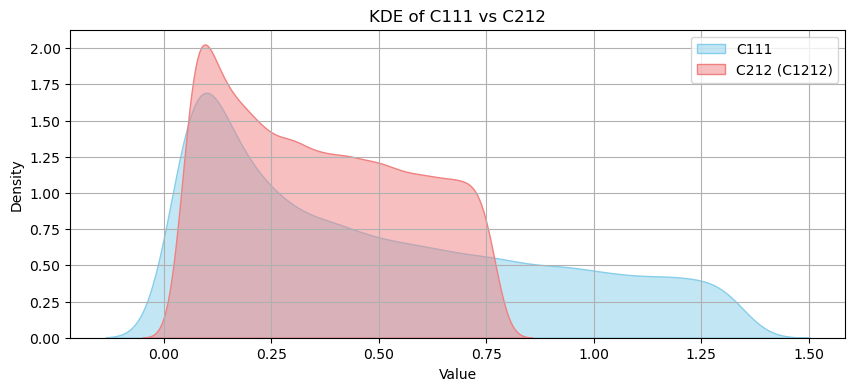


KS Test: D = 0.2621, p = 0 (p < 0.05 → significantly different)


In [ ]:
# === KDE Plot ===
plt.figure(figsize=(10, 4))
sns.kdeplot(C111, label='C111', fill=True, color='skyblue', alpha=0.5)
sns.kdeplot(C212, label='C212 (C1212)', fill=True, color='lightcoral', alpha=0.5)
plt.title("KDE of C111 vs C212")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# === KS Test ===
ks_stat, ks_pval = ks_2samp(C111, C212)
print(f"\nKS Test: D = {ks_stat:.4f}, p = {ks_pval:.4g} (p < 0.05 → significantly different)")


Pearson correlation with S[1]:
  C111: r = 0.1587
  C212: r = -0.0838


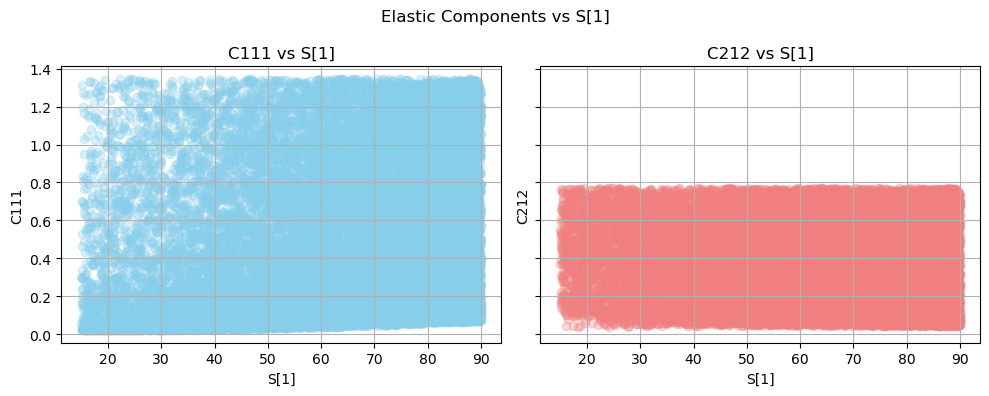


Pearson correlation with S[2]:
  C111: r = 0.1320
  C212: r = -0.0801


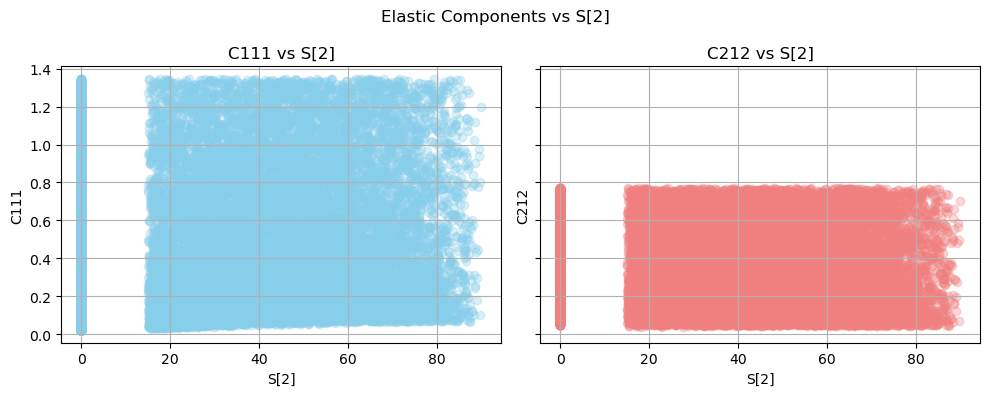


Pearson correlation with S[3]:
  C111: r = 0.0888
  C212: r = -0.0509


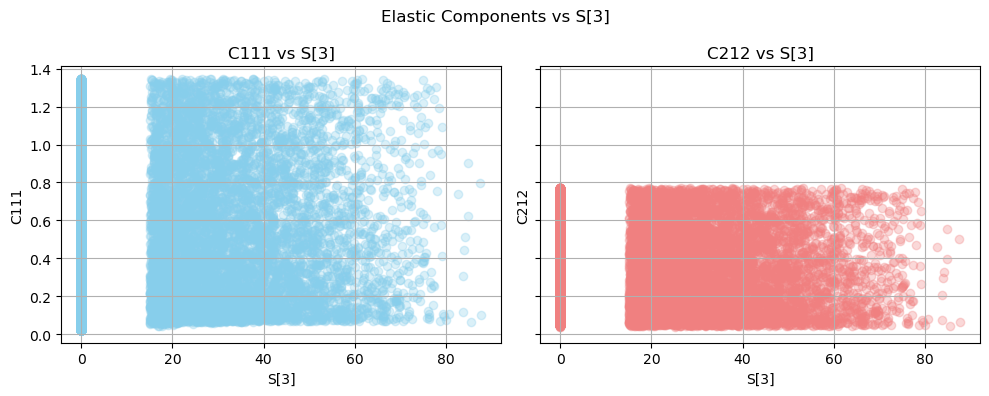


Pearson correlation with S[4]:
  C111: r = 0.9511
  C212: r = 0.9863


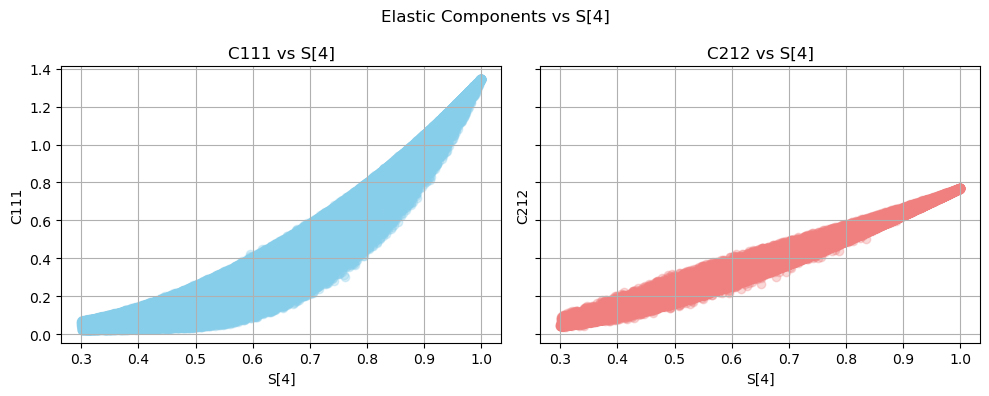

In [15]:
# === side-by-side scatter plots for C111 and C212 vs S[i] ===
for i in range(4):
    r_c111, _ = pearsonr(S[:, i], C111)
    r_c212, _ = pearsonr(S[:, i], C212)
    print(f"\nPearson correlation with S[{i+1}]:")
    print(f"  C111: r = {r_c111:.4f}")
    print(f"  C212: r = {r_c212:.4f}")

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    axs[0].scatter(S[:, i], C111, alpha=0.3, color='skyblue')
    axs[0].set_xlabel(f"S[{i+1}]")
    axs[0].set_ylabel("C111")
    axs[0].set_title(f"C111 vs S[{i+1}]")
    axs[0].grid(True)

    axs[1].scatter(S[:, i], C212, alpha=0.3, color='lightcoral')
    axs[1].set_xlabel(f"S[{i+1}]")
    axs[1].set_ylabel("C212")
    axs[1].set_title(f"C212 vs S[{i+1}]")
    axs[1].grid(True)

    plt.suptitle(f"Elastic Components vs S[{i+1}]")
    plt.tight_layout()
    plt.show()


Correlation between C111 and C212:
  Pearson : r = 0.9370
  Spearman: r = 0.9204


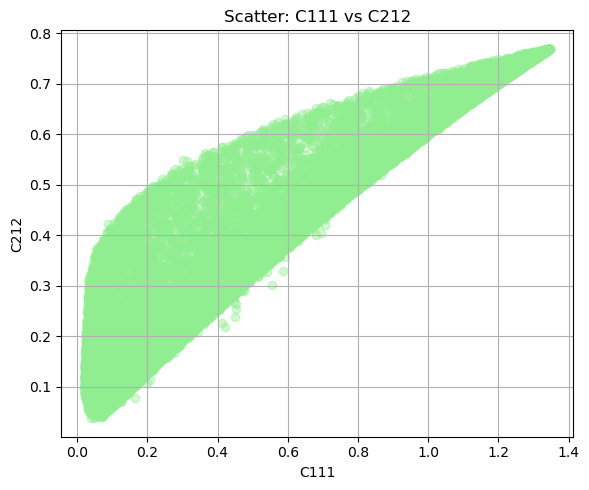

In [18]:
# === correlation between C111 and C212 ===
pearson, _ = pearsonr(C111, C212)
spearman, _ = spearmanr(C111, C212)
print(f"\nCorrelation between C111 and C212:")
print(f"  Pearson : r = {pearson:.4f}")
print(f"  Spearman: r = {spearman:.4f}")

# === joint scatter plot ===
plt.figure(figsize=(6, 5))
plt.scatter(C111, C212, alpha=0.4, color='lightgreen')
plt.xlabel("C111")
plt.ylabel("C212")
plt.title("Scatter: C111 vs C212")
plt.grid(True)
plt.tight_layout()
plt.show()

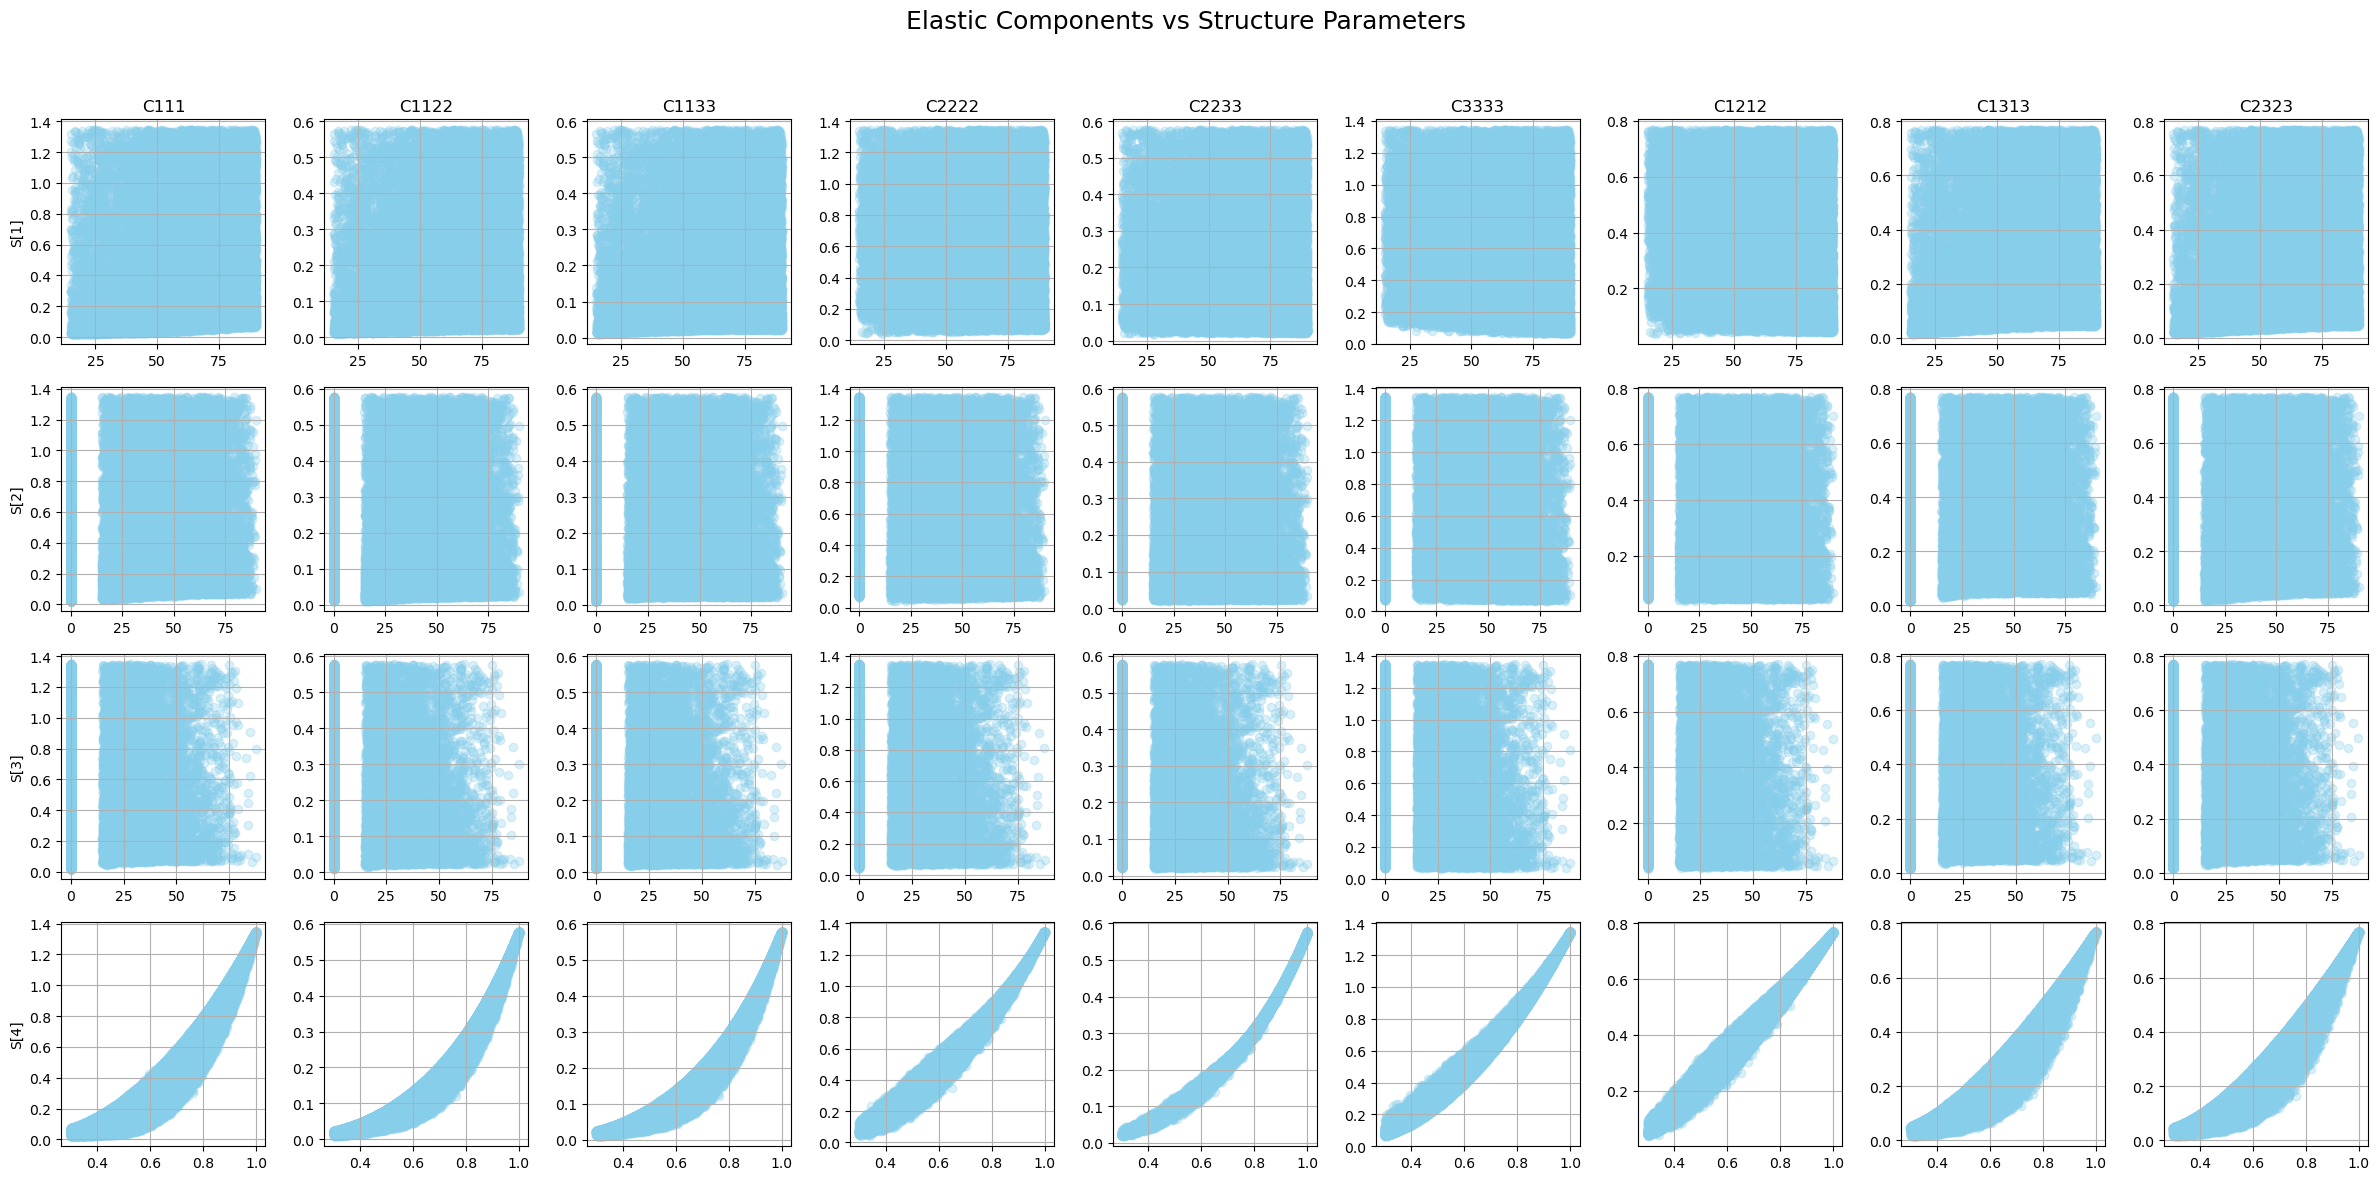

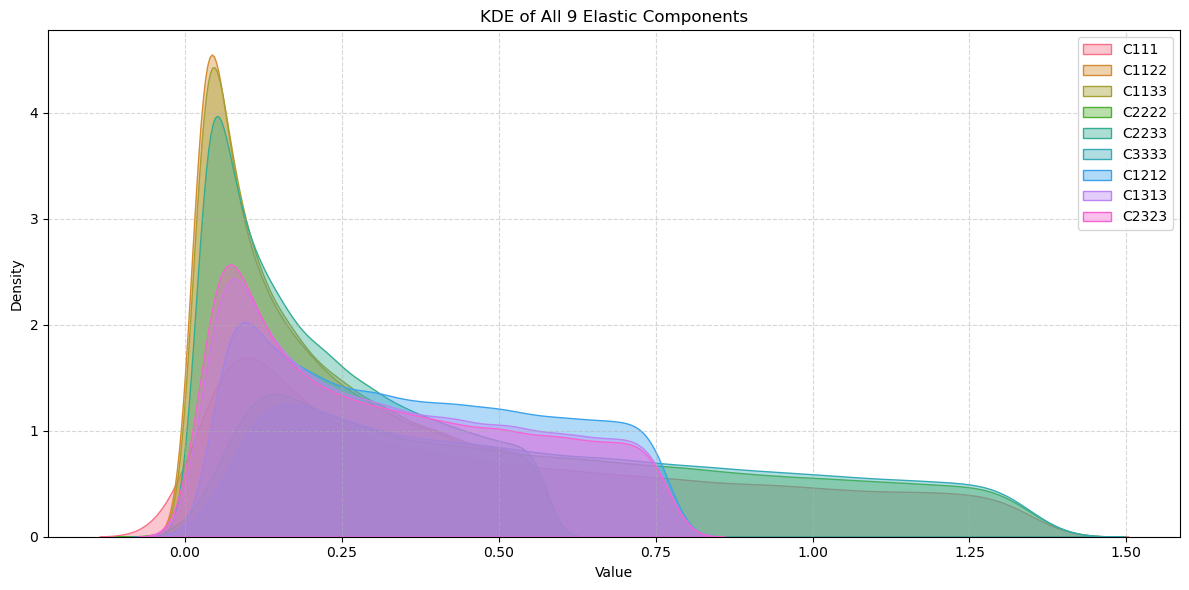

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.data_utils.load_data import load_dataset

# === Load your data ===
P, S = load_dataset("data/large_dataset.csv")
P = P.numpy()
S = S.numpy()

# === Labels ===
property_labels = [
    "C111", "C1122", "C1133", "C2222", "C2233", "C3333",
    "C1212", "C1313", "C2323"
]

structure_labels = [f"S[{i+1}]" for i in range(4)]

# === Plot each P[:, j] vs each S[:, i] ===
fig, axs = plt.subplots(4, 9, figsize=(24, 12), sharey='col')
fig.suptitle("Elastic Components vs Structure Parameters", fontsize=18)

for i in range(4):  # for each S[i]
    for j in range(9):  # for each P[j]
        ax = axs[i, j]
        ax.scatter(S[:, i], P[:, j], alpha=0.3, color='skyblue')
        if i == 0:
            ax.set_title(property_labels[j])
        if j == 0:
            ax.set_ylabel(f"{structure_labels[i]}")
        ax.set_xlabel("")
        ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === KDE Plot of all elastic components ===
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", len(property_labels))

for i in range(9):
    sns.kdeplot(P[:, i], fill=True, alpha=0.4, label=property_labels[i], color=colors[i])

plt.title("KDE of All 9 Elastic Components")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


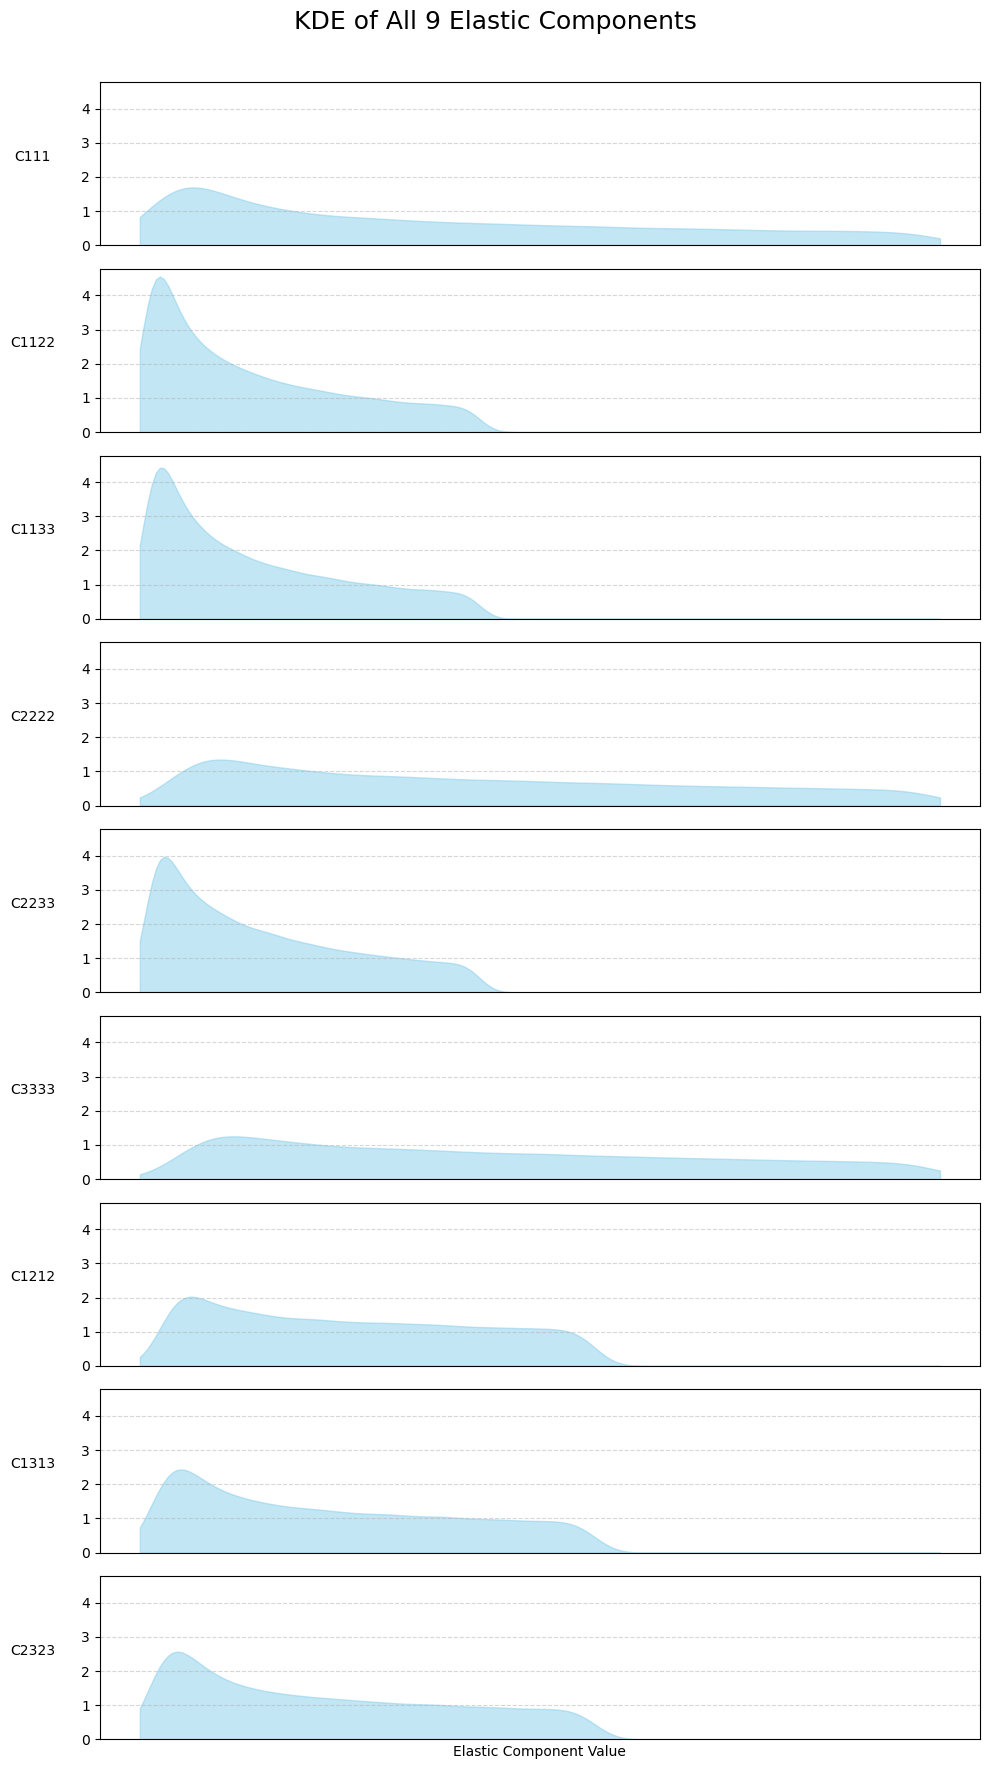

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from utils.data_utils.load_data import load_dataset

# === Load your data ===
P, S = load_dataset("data/large_dataset.csv")
P = P.numpy()

# === Labels ===
property_labels = [
    "C111", "C1122", "C1133", "C2222", "C2233", "C3333",
    "C1212", "C1313", "C2323"
]

# === Compute global x and y limits ===
x_vals = np.linspace(np.min(P), np.max(P), 200)
y_max = 0

# Compute KDEs and store max densities
kdes = []
for i in range(9):
    kde_func = gaussian_kde(P[:, i])
    y = kde_func(x_vals)
    y_max = max(y_max, np.max(y))
    kdes.append(y)

# === Plot all KDEs stacked vertically ===
fig, axs = plt.subplots(9, 1, figsize=(10, 18), sharex=True)
fig.suptitle("KDE of All 9 Elastic Components", fontsize=18)

for i in range(9):
    axs[i].fill_between(x_vals, kdes[i], color='skyblue', alpha=0.5)
    axs[i].set_ylabel(property_labels[i], rotation=0, labelpad=35, fontsize=10)
    axs[i].set_ylim(0, y_max * 1.05)
    axs[i].grid(True, linestyle='--', alpha=0.5)
    if i < 8:
        axs[i].set_xticks([])

axs[-1].set_xlabel("Elastic Component Value")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
